#  IN3050/IN4050 Mandatory Assignment 1: Traveling Salesman Problem

# Frida Berge (fridatbe)
- Run all to run my programs
- I've implemented each algorithm


## Rules
Before you begin the exercise, review the rules at this website: https://www.uio.no/english/studies/examinations/compulsory-activities/mn-ifi-mandatory.html, in particular the paragraph on cooperation. This is an individual assignment. You are not allowed to deliver together or copy/share source code/answers with others. Read also the "Routines for handling suspicion of cheating and attempted cheating at the University of Oslo": https://www.uio.no/english/studies/examinations/cheating/index.html. By submitting this assignment, you confirm that you are familiar with the rules and the consequences of breaking them.

### Delivery

**Deadline**: Friday, February 28 2025, 23:59

Your submission should be delivered in Devilry. You may redeliver in Devilry before the deadline, but include all files in the last delivery, as only the last delivery will be read. You are recommended to upload preliminary versions hours (or days) before the final deadline.

## What to deliver?

Deliver one single zipped folder (.zip, .tgz or .tar.gz) which includes:
* PDF report containing:
    * Your name and username (!)
    * Instructions on how to run your program, with example runs.
    * Answers to all questions from assignment.
    * Brief explanation of what you’ve done.
    * *Your PDF may be generated by exporting your Jupyter Notebook to PDF, if you have answered all questions in your notebook*
* Source code
    * Source code may be delivered as jupyter notebooks or python files (.py)
* The european cities file so the program will run right away.
* Any files needed for the group teacher to easily run your program on IFI linux machines.

**Important**: 
* Include example runs of your code by doing the reports described in the tasks. Simply implementing the code, but never running it will not give many points.
* Include the code that was used to make all reports. Do not include reports of performance and time without also including the code that was used to produce it.
* If you weren’t able to finish the assignment, use the PDF report to elaborate on what you’ve tried
and what problems you encountered. Students who have made an effort and attempted all parts of the assignment
will get a second chance even if they fail initially. This exercise will be graded PASS/FAIL.

## Introduction
In this exercise, you will attempt to solve an instance of the traveling salesman problem (TSP) using different
methods. The goal is to become familiar with evolutionary algorithms and to appreciate their effectiveness on a
difficult search problem. You have to use Python to solve the assignment. You must write
your program from scratch (but you may use non-EA-related libraries).


|  &nbsp;   | Barcelona | Belgrade |  Berlin | Brussels | Bucharest | Budapest |
|:---------:|:---------:|:--------:|:-------:|:--------:|:---------:|:--------:|
| Barcelona |     0     |  1528.13 | 1497.61 |  1062.89 |  1968.42  |  1498.79 |
|  Belgrade |  1528.13  |     0    |  999.25 |  1372.59 |   447.34  |  316.41  |
|   Berlin  |  1497.61  |  999.25  |    0    |  651.62  |  1293.40  |  1293.40 |
|  Brussels |  1062.89  |  1372.59 |  651.62 |     0    |  1769.69  |  1131.52 |
| Bucharest |  1968.42  |  447.34  | 1293.40 |  1769.69 |     0     |  639.77  |
|  Budapest |  1498.79  |  316.41  | 1293.40 |  1131.52 |   639.77  |     0    |


<center>Figure 1: First 6 cities from csv file.</center>


## Problem
The traveling salesman, wishing to disturb the residents of the major cities in some region of the world in
the shortest time possible, is faced with the problem of finding the shortest tour among the cities. A tour
is a path that starts in one city, visits all of the other cities, and then returns to the starting point. The
relevant pieces of information, then, are the cities and the distances between them. In this instance of the
TSP, a number of European cities are to be visited. Their relative distances are given in the data file, *european_cities.csv*, found in the zip file with the mandatory assignment.

(You will use permutations to represent tours in your programs. The **itertools** module in Python provides
a permutations function that returns successive permutations, this is useful for exhaustive search)

## Helper code for visualizing solutions

Here follows some helper code that you can use to visualize the plans you generate. These visualizations can **help you check if you are making sensible tours or not**. The optimization algoritms below should hopefully find relatively nice looking tours, but perhaps with a few visible inefficiencies.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline
np.random.seed(57)
#Map of Europe
europe_map = plt.imread('map.png')

#Lists of city coordinates
city_coords = {
    "Barcelona": [2.154007, 41.390205], "Belgrade": [20.46, 44.79], "Berlin": [13.40, 52.52], 
    "Brussels": [4.35, 50.85], "Bucharest": [26.10, 44.44], "Budapest": [19.04, 47.50],
    "Copenhagen": [12.57, 55.68], "Dublin": [-6.27, 53.35], "Hamburg": [9.99, 53.55], 
    "Istanbul": [28.98, 41.02], "Kyiv": [30.52, 50.45], "London": [-0.12, 51.51], 
    "Madrid": [-3.70, 40.42], "Milan": [9.19, 45.46], "Moscow": [37.62, 55.75],
    "Munich": [11.58, 48.14], "Paris": [2.35, 48.86], "Prague": [14.42, 50.07],
    "Rome": [12.50, 41.90], "Saint Petersburg": [30.31, 59.94], "Sofia": [23.32, 42.70],
    "Stockholm": [18.06, 60.33], "Vienna": [16.36, 48.21], "Warsaw": [21.02, 52.24]}


In [3]:
#Helper code for plotting plans
#First, visualizing the cities.
import csv
with open("european_cities.csv", "r") as f:
    data = list(csv.reader(f, delimiter=';'))
    cities = data[0]

fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(europe_map, extent=[-14.56, 38.43, 37.697 + 0.3, 64.344 + 2.0], aspect="auto")

# Map (long, lat) to (x, y) for plotting
for city, location in city_coords.items():
    x, y = (location[0], location[1])
    plt.plot(x, y, 'ok', markersize=5)
    plt.text(x, y, city, fontsize=12)


In [4]:
#A method you can use to plot your plan on the map.
def plot_plan(city_order):
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.imshow(europe_map, extent=[-14.56, 38.43, 37.697 + 0.3, 64.344 + 2.0], aspect="auto")

    # Map (long, lat) to (x, y) for plotting
    for index in range(len(city_order) - 1):
        current_city_coords = city_coords[city_order[index]]
        next_city_coords = city_coords[city_order[index+1]]
        x, y = current_city_coords[0], current_city_coords[1]
        #Plotting a line to the next city
        next_x, next_y = next_city_coords[0], next_city_coords[1]
        plt.plot([x, next_x], [y, next_y])

        plt.plot(x, y, 'ok', markersize=5)
        plt.text(x, y, index, fontsize=12)
    #Finally, plotting from last to first city
    first_city_coords = city_coords[city_order[0]]
    first_x, first_y = first_city_coords[0], first_city_coords[1]
    plt.plot([next_x, first_x], [next_y, first_y])
    #Plotting a marker and index for the final city
    plt.plot(next_x, next_y, 'ok', markersize=5)
    plt.text(next_x, next_y, index+1, fontsize=12)
    plt.show()


['Barcelona', 'Belgrade', 'Berlin', 'Brussels', 'Bucharest', 'Budapest', 'Copenhagen', 'Dublin', 'Hamburg', 'Istanbul', 'Kyiv', 'London', 'Madrid', 'Milan', 'Moscow', 'Munich', 'Paris', 'Prague', 'Rome', 'Saint Petersburg', 'Sofia', 'Stockholm', 'Vienna', 'Warsaw']


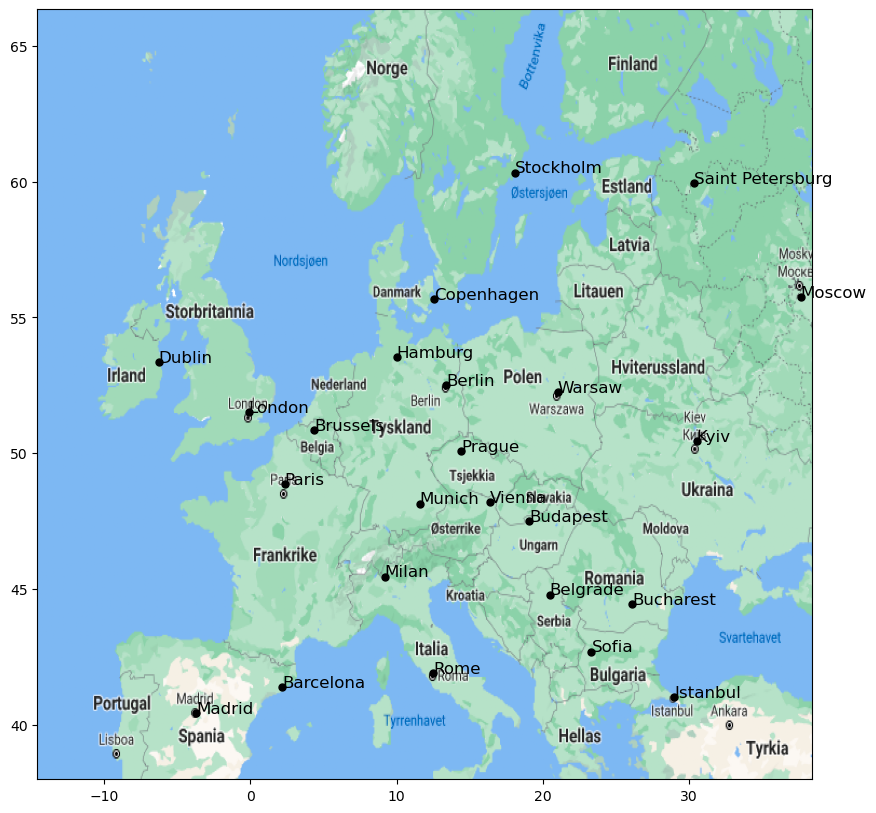

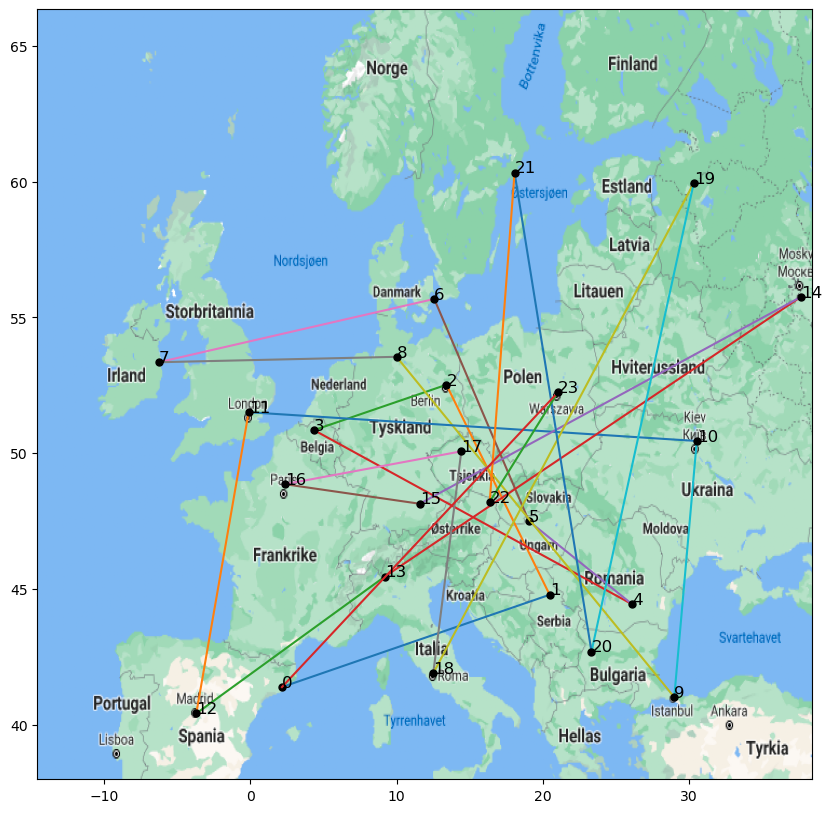

In [5]:
#Example usage of the plotting-method.
plan = list(city_coords.keys()) # Gives us the cities in alphabetic order
print(plan)
plot_plan(plan)

## Exhaustive Search
First, try to solve the problem by inspecting every possible tour. Start by writing a program to find the shortest
tour among a subset of the cities (say, **6** of them). Measure the amount of time your program takes. Incrementally
add more cities and observe how the time increases. Plot the shortest tours you found using the plot_plan method above, for 6 and 10 cities.

**Note:** To get distances between cities, use the dictionary `data` created by reading the file `european_cities.csv`. *Do not* calculate distances based on the coordinates. The actual distances do not only depend on the differences in the coordinates, but also of the curvature of the earth. The distances available in `data` are corrected for this, and contain the actual true distances.

Shortest path:  ('Barcelona', 'Belgrade', 'Bucharest', 'Budapest', 'Berlin', 'Brussels')
shortest Distance: 5018.8099999999995
Time spent: 0.003


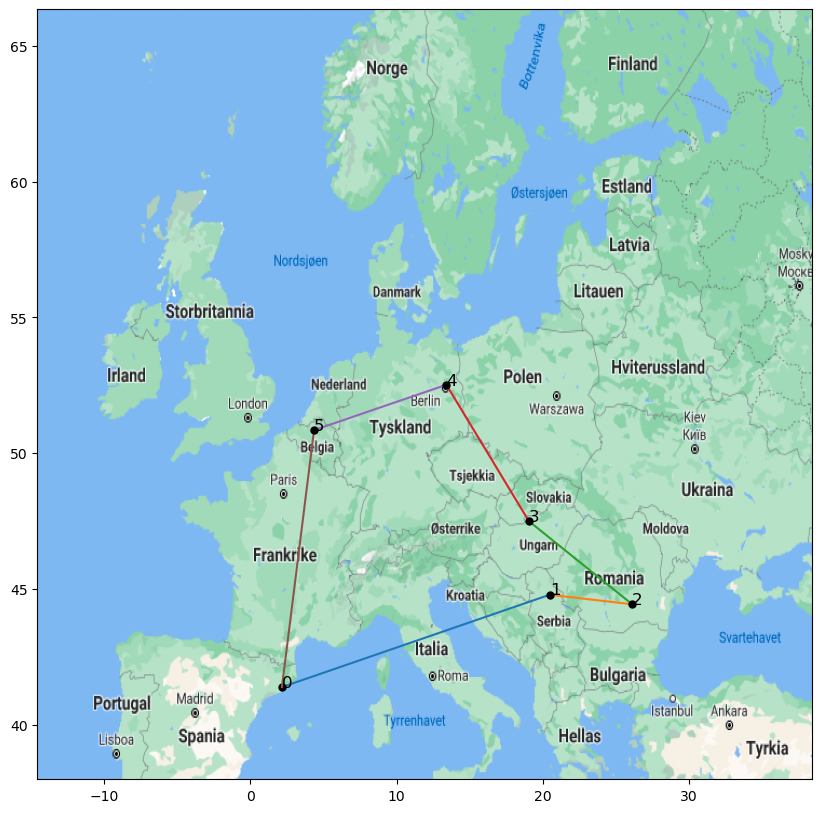

In [6]:
# Implement the algorithm here
import itertools as it
import time

def exh(numCities):
    shortestPath = [None]*numCities
    shortestDistance = np.inf
    path = data[0][0:numCities]

    per = it.permutations(path)
    for cities in per:
        totalDistance = 0.0
        # print(cities)
        for i in range(len(cities)):
            if(i < len(cities)-1):
                fromCityIndex = data[0].index(cities[i])
                toCityIndex = data[0].index(cities[i+1])
                # print("distance between ", data[0][fromCityIndex], " and ", data[0][toCityIndex], " ", data[fromCityIndex+1][toCityIndex])
            else:
                fromCityIndex = data[0].index(cities[i])
                toCityIndex = data[0].index(cities[0])
                # print("distance between ", data[0][fromCityIndex], " and ", data[0][toCityIndex], " ",data[fromCityIndex][toCityIndex])
            totalDistance += float(data[fromCityIndex+1][toCityIndex])
        # print("Total distance: ", totalDistance)
        if(totalDistance<shortestDistance):
            shortestDistance=totalDistance
            shortestPath=cities
    # print("Shortest distance:", np.round(shortestDistance,5))
    return shortestPath, shortestDistance

startTime = time.time()
shortestPath, shortestDistance = exh(6)
print("Shortest path: ", shortestPath)
print("shortest Distance:", shortestDistance)
endTime = time.time()
timeForTen = np.round(endTime-startTime,5)
print(f"Time spent: {timeForTen}")
plot_plan(shortestPath)


What is the shortest tour (i.e., the actual sequence of cities, and its length) among the first 10 cities (that is,
the cities starting with B,C,D,H and I)? How long did your program take to find it? Calculate an approximation of how long it would take to perform exhaustive search on all 24 cities?

Shortest path ('Copenhagen', 'Hamburg', 'Brussels', 'Dublin', 'Barcelona', 'Belgrade', 'Istanbul', 'Bucharest', 'Budapest', 'Berlin')
Time spent: 19.4557


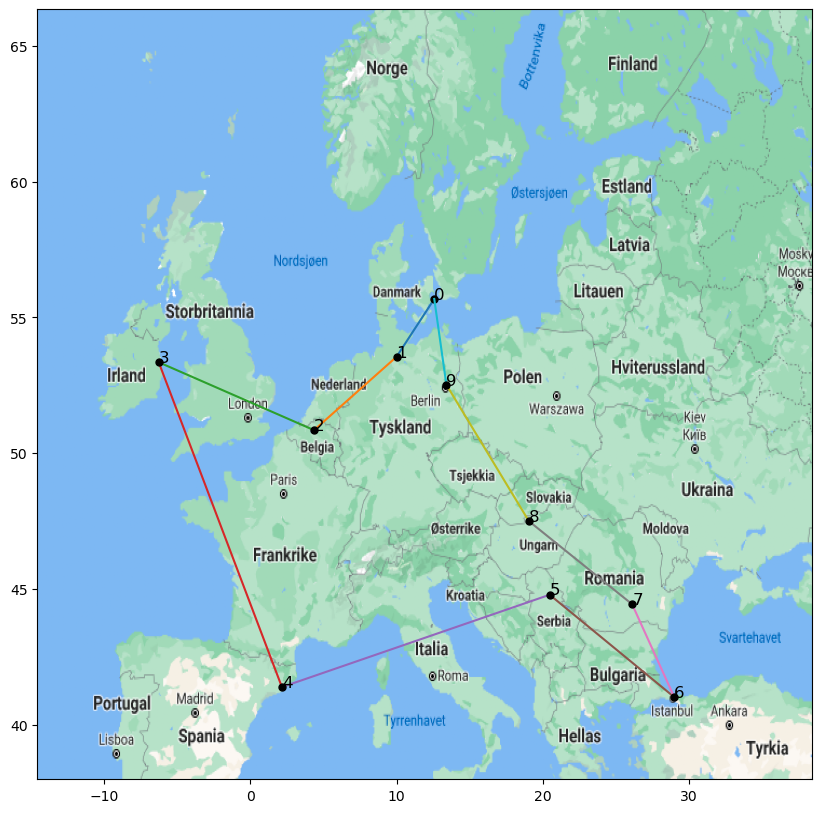

Approximation of time spent for 24 cities:  1.2071257969601385e+25


In [7]:
# Answer
#shortest path was:('Copenhagen', 'Hamburg', 'Brussels', 'Dublin', 'Barcelona', 'Belgrade', 'Istanbul', 'Bucharest', 'Budapest', 'Berlin')
#the total distance was: 7486.31
#It took 19.98044 seconds to find the solution
#It will take 24!-10! more time. The formula for 24 cities will then be: 19.98044*(24!-10!)seconds
import math

startTime = time.time()
shortestPath,shortestDistance = exh(10)
print("Shortest path", shortestPath)
endTime = time.time()
timeForTen = np.round(endTime-startTime,5)
print(f"Time spent: {timeForTen}")
plot_plan(shortestPath)

total = math.factorial(24)
ten = math.factorial(10)
print("Approximation of time spent for 24 cities: ", (total-ten)*timeForTen)

## Hill Climbing
Then, write a simple hill climber to solve the TSP. How well does the hill climber perform, compared to the result from the exhaustive search for the first **10 cities**? Since you are dealing with a stochastic algorithm, you
should run the algorithm several times to measure its performance. Report the length of the tour of the best,
worst and mean of 20 runs (with random starting tours), as well as the standard deviation of the runs, both with the **10 first cities**, and with all **24 cities**. Plot one of the the plans from the 20 runs for both 10 cities and 24 cities (you can use plot_plan). 

Best of 10 cities:
	Distance: 10369.47
	Path: ['Berlin', 'Dublin', 'Barcelona', 'Belgrade', 'Copenhagen', 'Hamburg', 'Brussels', 'Budapest', 'Bucharest', 'Istanbul']
Worst of 10 cities:
	Distance: 14686.75
	Path: ['Belgrade', 'Budapest', 'Dublin', 'Istanbul', 'Hamburg', 'Bucharest', 'Berlin', 'Brussels', 'Copenhagen', 'Barcelona']
Mean of 10 cities:
	 252319.03/10=25231.903
Standard deviation for 10 cities: 933.11168
10 cities compared to exhausive search:
	 Distance of mean - Distance of exhaustive search: 252319.03-7486.31=244833.0

Best of 24 cities:
	Distance: 27941.37
	Path: ['Prague', 'Berlin', 'Saint Petersburg', 'London', 'Hamburg', 'Warsaw', 'Barcelona', 'Dublin', 'Budapest', 'Copenhagen', 'Moscow', 'Stockholm', 'Sofia', 'Bucharest', 'Madrid', 'Brussels', 'Paris', 'Milan', 'Kyiv', 'Istanbul', 'Munich', 'Vienna', 'Rome', 'Belgrade']
Worst of 24 cities:
	Distance: 35270.26
	Path: ['Belgrade', 'Stockholm', 'Madrid', 'Hamburg', 'Rome', 'Moscow', 'Sofia', 'Berlin', 'Milan', 'Kyiv',

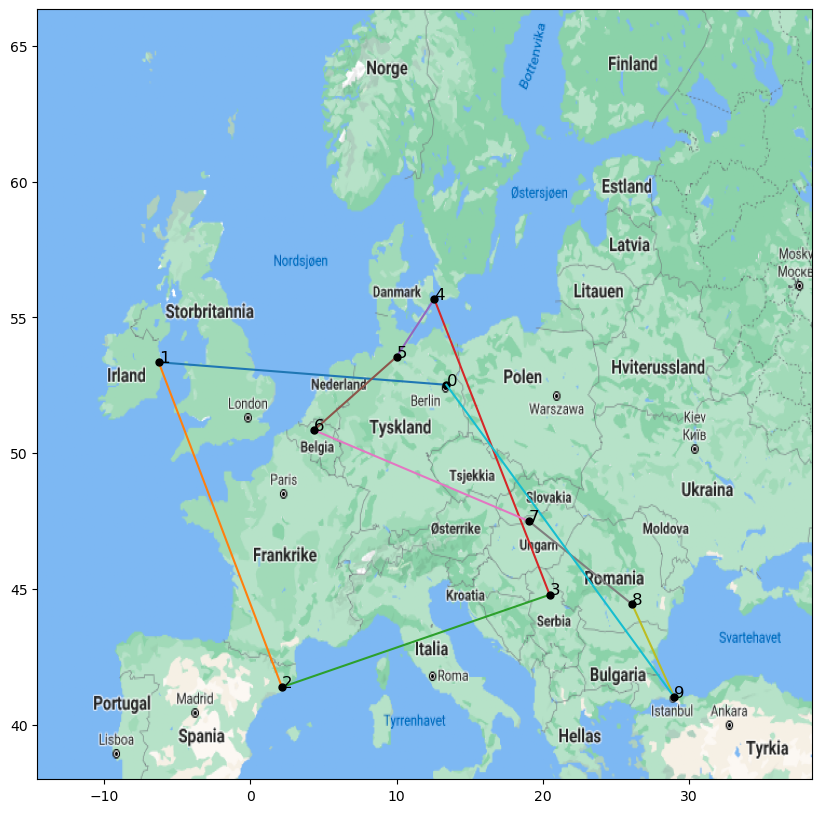

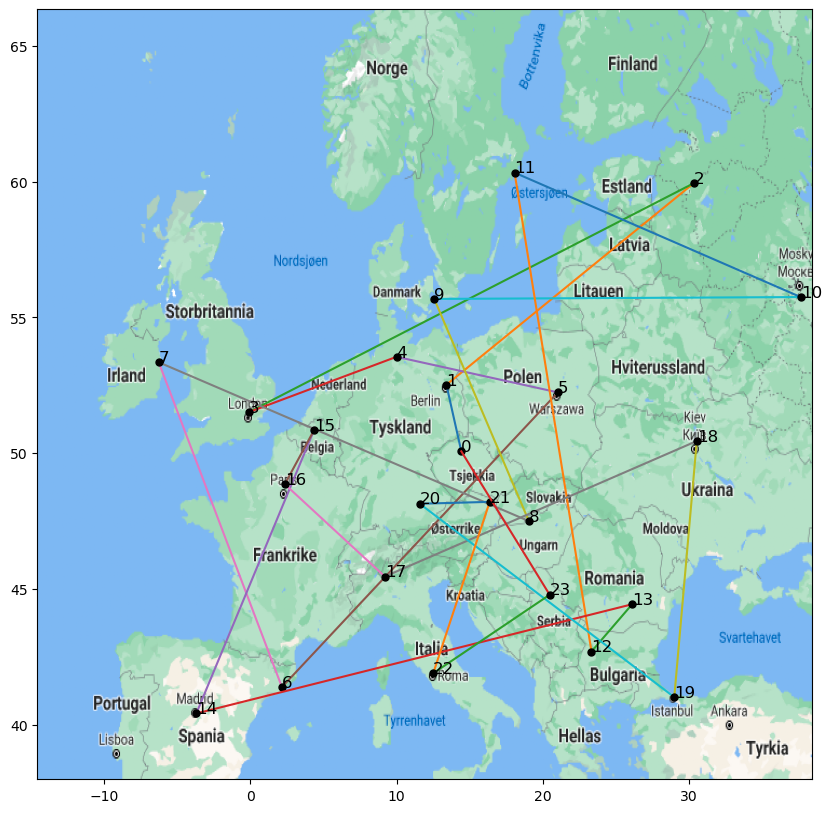

In [8]:
# Implement the algorithm here
import random

def calculate(cities, shortestDistance, shortestPath, better):
    totalDistance = 0.0

    #calculates the distance between each city in a path
    for i in range(len(cities)):
        if(i < len(cities)-1):
            fromCityIndex = data[0].index(cities[i])
            toCityIndex = data[0].index(cities[i+1])
            # print("distance between ", data[0][fromCityIndex], " and ", data[0][toCityIndex], " ", data[fromCityIndex+1][toCityIndex])
        else:
            fromCityIndex = data[0].index(cities[i])
            toCityIndex = data[0].index(cities[0])
            # print("distance between ", data[0][fromCityIndex], " and ", data[0][toCityIndex], " ",data[fromCityIndex][toCityIndex])
        totalDistance += float(data[fromCityIndex+1][toCityIndex])

    #updates shortest if better than the best
    if(totalDistance<shortestDistance):
        shortestDistance=np.round(totalDistance,5)
        shortestPath=cities
        better = 1
    else:
        better = 0
    return shortestDistance, shortestPath, better


def hillClimb(numCities):
    np.random.seed(None)
    better = 1

    #Making a random initial path
    shortestPath = [None]*numCities
    nFirst = list(data[0][0:numCities])
    j = 0
    while len(nFirst)>0:
        ran = random.randint(0,len(nFirst)-1)
        shortestPath[j] = nFirst.pop(ran)
        j+=1

    #calculating path. first initial run
    shortestDistance, shortestPath, better = calculate(shortestPath, np.inf, [None]*numCities, better)

    #runs until there are no better neighbour (local optima), (until better = 0)
    while(better == 1):
        #finding one neighbour
        child = shortestPath.copy()
        ran = random.randint(0,len(child)-1)
        if(ran >= len(child)-1):
            value = child[ran]
            child[ran] = child[ran-1]
            child[ran-1] = value
        else:
            value = child[ran]
            child[ran] = child[ran+1]
            child[ran+1] = value

        #updates the distance and path if a the neighbour is better
        shortestDistance, shortestPath, better = calculate(child, shortestDistance, shortestPath, better)
    return shortestDistance, shortestPath


def analyze(numCities):
    distances = [0.0]*20
    worstPath = [None]*numCities
    bestPath = [None]*numCities
    worstDist = 0
    bestDist = np.inf

    #doing 20 iterations
    for i in range(20):
        distances[i], path = hillClimb(numCities)
        if(distances[i]<bestDist):
            bestDist = distances[i]
            bestPath = path
        if(distances[i]>worstDist):
            worstDist = distances[i]
            worstPath = path
    
    mean = np.round(sum(distances),5)
    print(f"Best of {numCities} cities:\n\tDistance: {bestDist}\n\tPath: {bestPath}")
    print(f"Worst of {numCities} cities:\n\tDistance: {worstDist}\n\tPath: {worstPath}")
    print(f"Mean of {numCities} cities:\n\t {mean}/{numCities}={np.round(mean/numCities,5)}")
    print(f"Standard deviation for {numCities} cities: {np.round(np.std(distances),5)}")
    if(numCities==10):
        print(f"10 cities compared to exhausive search:\n\t Distance of mean - Distance of exhaustive search: {mean}-{7486.31}={np.round(mean-7486.31)}\n")
    else:
        print("\n")
    return bestPath

#running the agorithm
best10 = analyze(10)
best24 = analyze(24)


#printing the best paths
plot_plan(best10)
plot_plan(best24)




## Genetic Algorithm
Next, write a genetic algorithm (GA) to solve the problem. Choose mutation and crossover operators that are appropriate for the problem (see chapter 4.5 of the Eiben and Smith textbook). Choose three different values for the population size. Define and tune other parameters yourself and make assumptions as necessary (and report them, of course).

For all three variants: As with the hill climber, report best, worst, mean and standard deviation of tour length out of 20 runs of the algorithm (of the best individual of last generation). Also, find and plot the average fitness of the best fit individual in each generation (average across runs), and include a figure with all three curves in the same plot in the report. This means that the x-axis should be the generations over time and the y-axis should be the average (over the 20-runs) fitness of the best gene in that generation. Conclude which is best in terms of tour length and number of generations of evolution time.

Finally, plot an example optimized tour (the best of the final generation) for the three different population sizes, using the plot_plan method.

For 10 in population size:
Best of 24 cities:
	Distance: 17921.39
	Path: ['Brussels', 'Munich', 'Prague', 'Budapest', 'Bucharest', 'Istanbul', 'Sofia', 'Rome', 'Madrid', 'Paris', 'Copenhagen', 'Hamburg', 'Barcelona', 'Milan', 'Berlin', 'Warsaw', 'Stockholm', 'Saint Petersburg', 'Moscow', 'Kyiv', 'Belgrade', 'Vienna', 'Dublin', 'London']
Worst of 24 cities:
	Distance: 25038.469999999998
	Path: ['Barcelona', 'Milan', 'Berlin', 'Saint Petersburg', 'London', 'Dublin', 'Madrid', 'Belgrade', 'Copenhagen', 'Moscow', 'Istanbul', 'Rome', 'Vienna', 'Prague', 'Stockholm', 'Bucharest', 'Sofia', 'Munich', 'Warsaw', 'Kyiv', 'Budapest', 'Hamburg', 'Brussels', 'Paris']
Mean of 24 cities:
	 429963.63/24=17915.15125
Standard deviation for 24 cities: 2217.1684


For 50 in population size:
Best of 24 cities:
	Distance: 14265.27
	Path: ['Berlin', 'Munich', 'London', 'Dublin', 'Brussels', 'Paris', 'Madrid', 'Barcelona', 'Rome', 'Milan', 'Prague', 'Vienna', 'Belgrade', 'Bucharest', 'Istanbul', 'Sofia', 'Buda

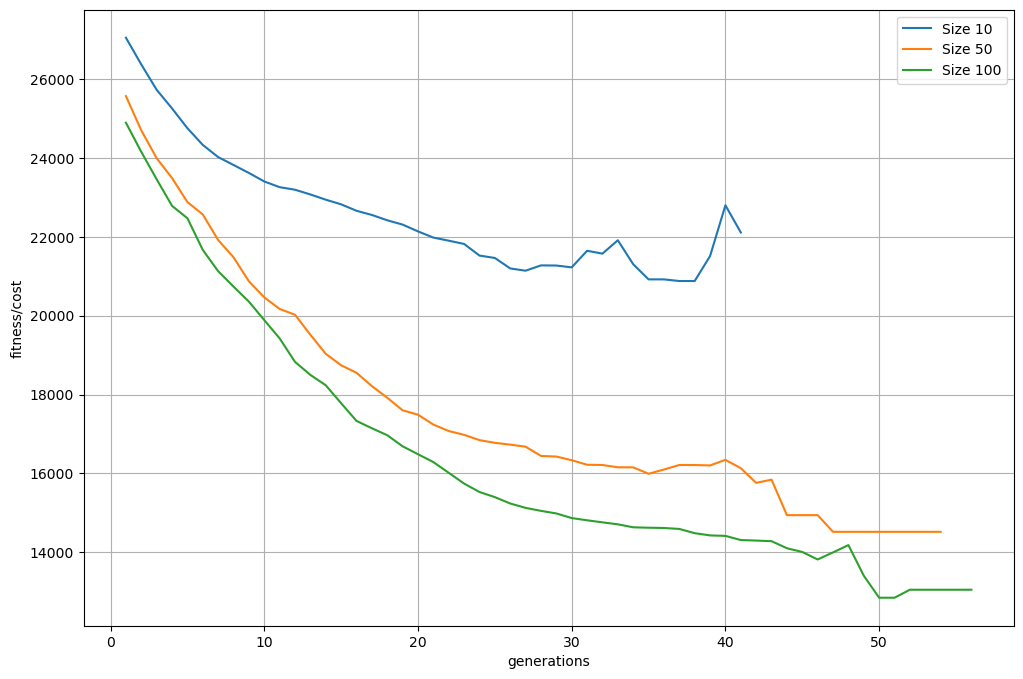

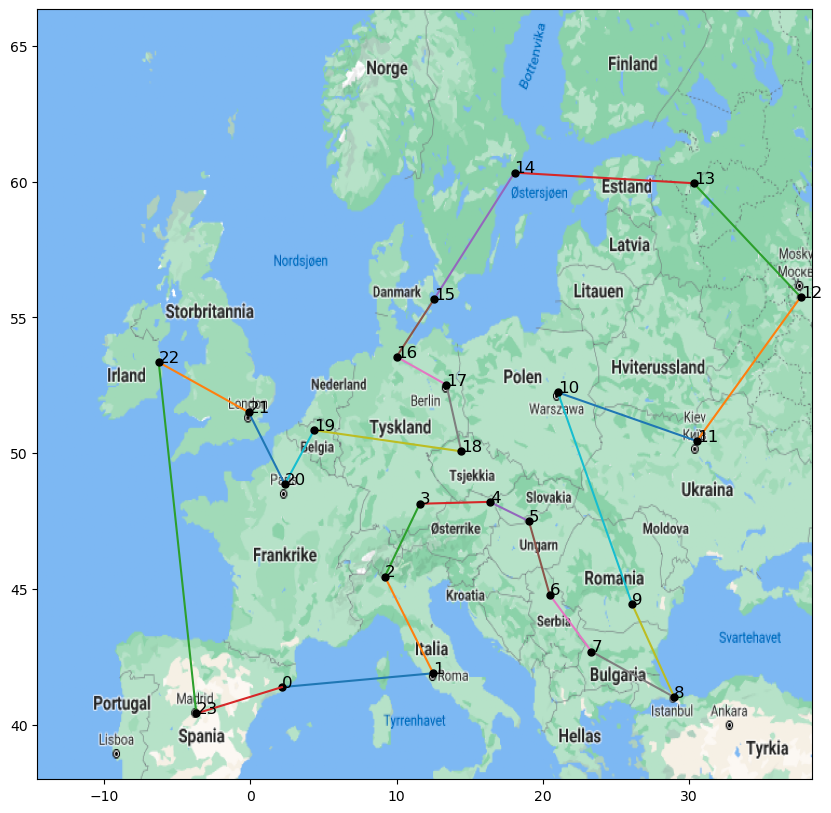

['Barcelona', 'Rome', 'Milan', 'Munich', 'Vienna', 'Budapest', 'Belgrade', 'Sofia', 'Istanbul', 'Bucharest', 'Warsaw', 'Kyiv', 'Moscow', 'Saint Petersburg', 'Stockholm', 'Copenhagen', 'Hamburg', 'Berlin', 'Prague', 'Brussels', 'Paris', 'London', 'Dublin', 'Madrid']


In [17]:
# Implement the algorithm here
import matplotlib.pyplot as plt

#supporting functions
# /////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////

def calculateDistance(cities):
    totalDistance = 0.0
    #calculates the distance between each city in a path
    for i in range(len(cities)):
        if(i < len(cities)-1):
            fromCityIndex = data[0].index(cities[i])
            toCityIndex = data[0].index(cities[i+1])
        else:
            fromCityIndex = data[0].index(cities[i])
            toCityIndex = data[0].index(cities[0])
        totalDistance += float(data[fromCityIndex+1][toCityIndex])
    return totalDistance

def placeAlelleSegment(alToPlace,al,c,p,index):
    #if they hae equal values in same spot
    if(alToPlace in c):
        return c
    elif(c[index] != None):
        alelleChild = c[index]
        placeAlelleSegment(alToPlace,alelleChild,c,p,p.index(alelleChild))
        return c
    c[index] = alToPlace
    return c

def pmx(p1,p2):
    c = [None]*len(p1)
    segmSize = int(len(p1)/2)
    #copy segment from parent 1
    startCopy = random.randint(0,len(p1)-segmSize)
    segmentP2 = [0]*segmSize
    start = startCopy
    for i in range(segmSize):
        c[start] = p1[start]
        segmentP2[i] = p2[start]
        start+=1
    #place parts of segment from parent 2 to child
    start2 = startCopy
    for alelle in segmentP2:
        placeAlelleSegment(alelle,alelle,c,p2,start2)
        start2+=1
    j = 0
    for i in range(len(p2)):
        if(c[i] == None):
            c[i] = p2[i]
    return c

def pmx_pair(a,b):
    return pmx(a,b),pmx(b,a)

# ///////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////



#initialization
def initialise(size, numCities):
    if(size>math.factorial(numCities)):
        print("Some of the individuals will be the same, choose a higher number of cities")
        return None
    
    population = [[None for path in range(numCities)] for individual in range(size)]

    #Making 'size' random initial paths
    for i in range(size):
        j = 0
        nFirst = data[0][0:numCities]
        path = [None]*numCities
        while len(nFirst)>0:
            ran = random.randint(0,len(nFirst)-1)
            path[j] = nFirst.pop(ran)
            j+=1
        population[i] = path
    return population

#Parent selection. Fitness-propotionate selection
#choosing the individuals based on a probability based on their fitness
def selectParents(population, distance):
    p = [0]*len(population)
    parents = []

    for i in range(len(population)):
        distance[i] = calculateDistance(population[i])

    #assigning probabilities to be chosen. 
    # we want the probability for low cost/short total distance to be higher
    for i in range(len(population)-1):
        p[i] = 1-distance[i]/sum(distance)

    #want to have half the number of the old population as parents
    for i in range(int(len(population)/2)):
        parents.append(random.choices(population,p)[0])

    #if we only have one individual
    if(len(population)<=1):
        parents = population
    return parents, distance

#Recombination. choosing uniform crossover as crossover method
def recombination(parents):

    #we cant make offspring from just one parent
    if(len(parents)<=1):
        return parents
    newOffspring = []

    for i in range(len(parents)-1):
        n1,n2 = pmx_pair(parents[i],parents[i+1])
        newOffspring.append(n1)
        newOffspring.append(n2)
        i+=1
    return newOffspring

#Mutation, mutates by switching neighbours
def mutation(offspring):
    newOffspring = []
    for path in offspring:
        child = path.copy()
        ran = random.randint(0,len(child)-1)
        if(ran >= len(child)-1):
            value = child[ran]
            child[ran] = child[ran-1]
            child[ran-1] = value
        else:
            value = child[ran]
            child[ran] = child[ran+1]
            child[ran+1] = value
        newOffspring.append(path)
        newOffspring.append(child)
    return newOffspring

#Survivor selection. Choosing survivors from both the best parents and offspring (elitism)
def selectSurvivors(oldPopulation,offspring,distance):
    survivors = oldPopulation.copy()
    distances = distance.copy()

    #if the child i had a lower cost than the worst parent, the parent will be replaced
    for i in range(len(offspring)-1):
        dist = calculateDistance(offspring[i])
        highest = max(distances)
        if(dist<highest):
            changeAtIndex = distances.index(highest)
            survivors[changeAtIndex] = offspring[i]
            distances[changeAtIndex] = dist
    return survivors,distances

#Terminaton. Stops when there is no fitness improvement of the average 5 times
def evaluate(population, oldD, newD, count):
    avgOld = sum(oldD)/len(oldD)
    avgNew = sum(newD)/len(newD)
    if(avgNew>=avgOld):
        count +=1
        if(count >= 5):
            return False,count
    return True,count

def GA(populationSize, numCities):
    term = 1
    count = 0
    population = initialise(populationSize, numCities)
    numPaths = len(population)
    newDist = [[None for path in range(numCities)] for individual in range(populationSize)]
    generationCount = 0
    y_axis = []
    x_axis = []
    x = []
    y = []
    while(term):
        parents, dist = selectParents(population, [0]*len(population))
        offspring = recombination(parents)
        offspring = mutation(offspring)
        numPaths += len(offspring)
        population,newDist = selectSurvivors(population,offspring,dist)
        term,count = evaluate(population,dist,newDist, count)

        #the best of each generation
        generationCount += 1
        x_axis.append(generationCount)
        bestIndividual = population[0]
        shortestDist = newDist[0]
        for i in range(len(population)-1):
            if(newDist[i+1]<shortestDist):
                shortestDist = newDist[i+1]
                bestIndividual = population[i+1]
        y_axis.append(shortestDist)
    return bestIndividual, shortestDist, numPaths,x_axis,y_axis

def analyzeGA(populationSize, numCities):
    numIterations = 20
    distances = [0]*numIterations
    worstPath = [None]*numCities
    bestPath = [None]*numCities
    worstDist = 0.0
    bestDist = np.inf
    pathsCount = 0
    Ys = []
    Xs = [0]*1
    numYs = []

    #doing the iterations
    for i in range(numIterations):
        individual,distance,pc,x,y = GA(populationSize,numCities)
        pathsCount +=pc
        if(distance<bestDist):
            bestDist = distance
            bestPath = individual
        if(distance>worstDist):
            worstDist = distance
            worstPath = individual
        distances[i] = distance
        Ys.append(y)
        if(len(x)>len(Xs)):
            Xs = x
    avgPathCount = pathsCount/numIterations
    sumY = [0]*100
    numGeneration = [0]*100
    length = 0
    for i in range(numIterations):
        for j in range(len(Ys[i])):
            sumY[j] += Ys[i][j]
            numGeneration[j] += 1
            length += 1
    avgY = [0]*len(Xs)
    for k in range(len(Xs)):
        avgY[k] = sumY[k]/numGeneration[k]

    #I chose the number of generations to be a non-fixed number, so iterations have different numbers of generations.
    #Plot the points defined by x_scatter and y_scatter
    x_values = Xs
    y_values = avgY    

    mean = np.round(sum(distances),5)
    if(numCities == 24):
        print_results(mean, distances, bestDist, bestPath, worstDist, worstPath, numCities, populationSize)
    return bestPath, bestDist, avgPathCount,x_values, y_values

def print_results(mean, distances, bestDist, bestPath, worstDist, worstPath, numCities, populationSize):
    print(f"For {populationSize} in population size:")
    print(f"Best of {numCities} cities:\n\tDistance: {bestDist}\n\tPath: {bestPath}")
    print(f"Worst of {numCities} cities:\n\tDistance: {worstDist}\n\tPath: {worstPath}")
    print(f"Mean of {numCities} cities:\n\t {mean}/{numCities}={np.round(mean/numCities,5)}")
    print(f"Standard deviation for {numCities} cities: {np.round(np.std(distances),5)}")
    if(numCities==10):
        print(f"10 cities compared to exhausive search:\n\t Distance of mean - Distance of exhaustive search: {mean}-{7486.31}={np.round(mean-7486.31)}\n")
    else:
        print("\n")

    
def bestofThree(i1,i2,i3, NumberofCities):
    besti,disti,pathC1,x1,y1 = analyzeGA(i1, NumberofCities)
    bestj,distj,pathC2,x2,y2 = analyzeGA(i2,NumberofCities)
    bestk,distk,pathC3,x3,y3 = analyzeGA(i3,NumberofCities)
    pathCountAvg = (pathC1+pathC2+pathC3)/3
    bestOnes = [besti, bestj, bestk]
    lowestOnes = [disti,distj,distk]
    lowest = min(lowestOnes)
    lowestIndex = lowestOnes.index(lowest)
    best = bestOnes[lowestIndex]

    plt.figure(figsize=(12,8))
    plt.plot(x1, y1, label=f'Size {i1}')
    plt.plot(x2, y2, label=f'Size {i2}')
    plt.plot(x3, y3, label=f'Size {i3}')
    plt.xlabel("generations")
    plt.ylabel("fitness/cost")
    plt.grid(True)
    plt.legend()
    plt.show()
    return best,lowest,pathCountAvg

#running the code
# ////////////////////////////////////////////////////////////////////////////////////////////
#running the agorithm
cities = 24
popSize1 = 10
popSize2 = 50
popSize3 = 100
bestSolution,lowestDist,pathsCounted = bestofThree(popSize1, popSize2, popSize3, cities)

# #printing the best paths
plot_plan(bestSolution)
print(bestSolution)




Among the first 10 cities, did your GA find the shortest tour (as found by the exhaustive search)? Did it come close? 

For both 10 and 24 cities: How did the running time of your GA compare to that of the exhaustive search? 

How many tours were inspected by your GA as compared to by the exhaustive search?

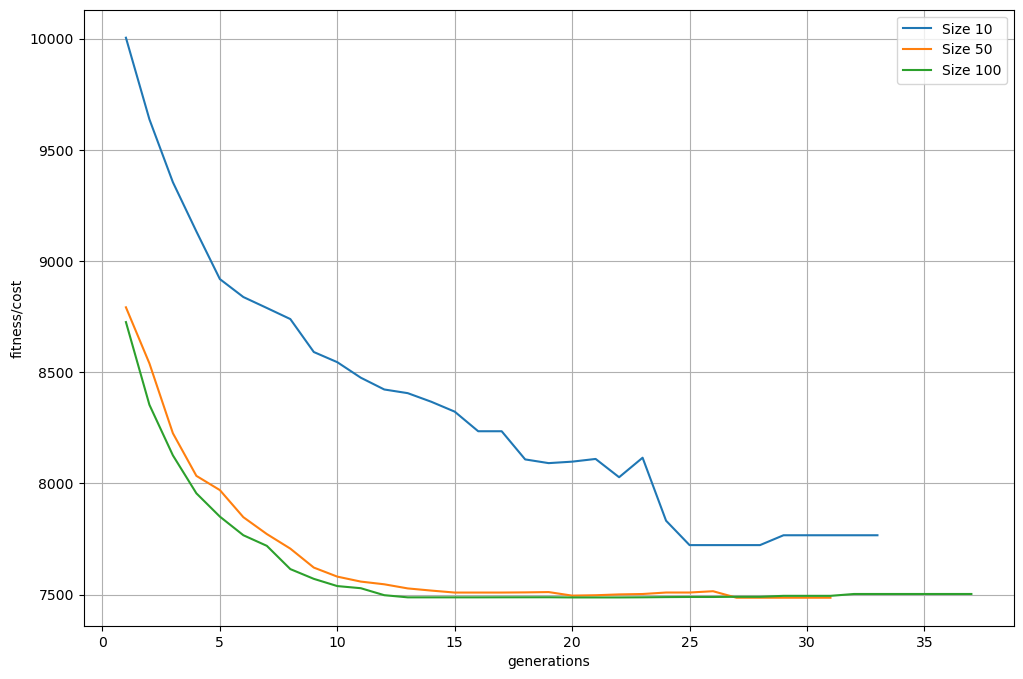

The shortest path was found
Time spent for 10 cities: 2.18603
Time compared to exhaustive search: time of exhaustive search - time of GA = 19.4557-2.18603=17.0
For 10 in population size:
Best of 24 cities:
	Distance: 18463.18
	Path: ['London', 'Brussels', 'Prague', 'Milan', 'Barcelona', 'Madrid', 'Warsaw', 'Kyiv', 'Bucharest', 'Istanbul', 'Sofia', 'Belgrade', 'Budapest', 'Hamburg', 'Moscow', 'Saint Petersburg', 'Stockholm', 'Copenhagen', 'Berlin', 'Dublin', 'Paris', 'Munich', 'Vienna', 'Rome']
Worst of 24 cities:
	Distance: 25453.170000000006
	Path: ['Belgrade', 'Budapest', 'Berlin', 'Prague', 'Vienna', 'Barcelona', 'Munich', 'Kyiv', 'Warsaw', 'Copenhagen', 'Moscow', 'Bucharest', 'Sofia', 'London', 'Dublin', 'Brussels', 'Saint Petersburg', 'Istanbul', 'Milan', 'Madrid', 'Paris', 'Hamburg', 'Stockholm', 'Rome']
Mean of 24 cities:
	 425216.57/24=17717.35708
Standard deviation for 24 cities: 1691.7343


For 50 in population size:
Best of 24 cities:
	Distance: 14207.610000000002
	Path: ['I

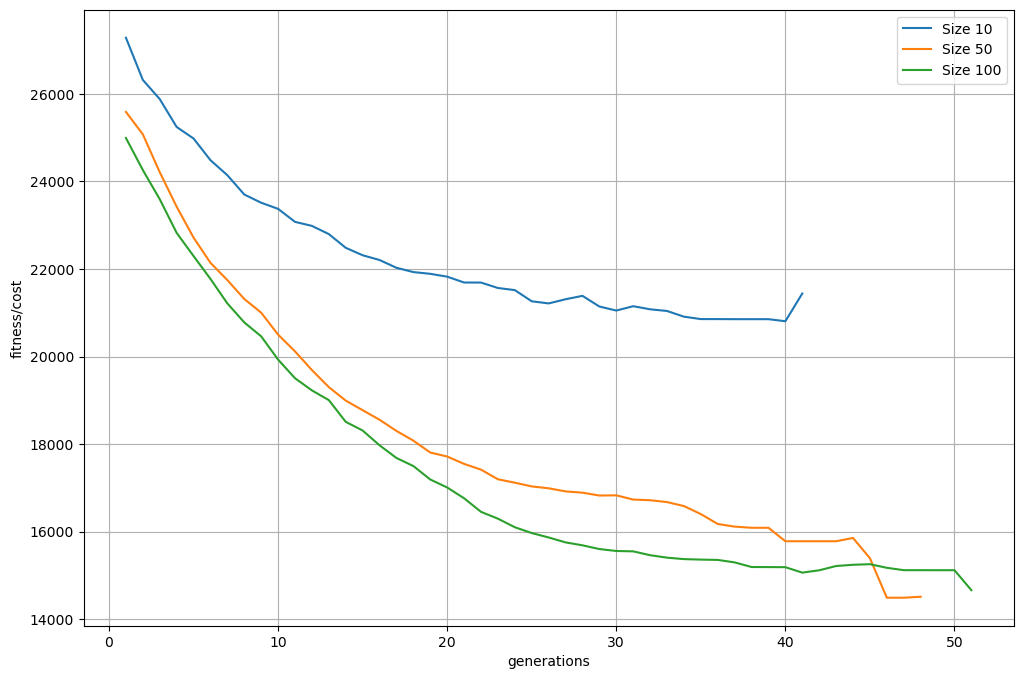

Time spent for 24 cities: 8.7461
Time compared to exhaustive search: time of exhaustive search - time of GA = 1.2071257969601385e+25-8.7461=1.2071257969601385e+25
Number of paths inspected in ...
GA (avg): 4293.0 	Exhaustive (calculated): 3628800


In [18]:
# Answer
#find the shortest tour? values are taken from previous task (shortestDistance and shortestPath)
startTime = time.time()
NumberofCities = 10
bestSolution_10,lowestDist_10,pathsCounted_10 = bestofThree(popSize1, popSize2, popSize3, NumberofCities)
endTime = time.time()
if(list(shortestPath) == bestSolution_10):
    print("The shortest path was found")
else:
    print("The shortest path was not found")
    print(f"GA was {np.round(lowestDist_10,7)}-{np.round(shortestDistance,7)}={np.round(lowestDist_10-shortestDistance,7)} from the result of exhaustive search")
print(f"Time spent for 10 cities: {np.round(endTime-startTime,5)}")
print(f"Time compared to exhaustive search: time of exhaustive search - time of GA = {timeForTen}-{np.round(endTime-startTime,5)}={np.round(timeForTen-np.round(endTime-startTime,5))}")

#for 24
startTime = time.time()
NumberofCities = 24
bestofThree(10,50,100, NumberofCities)
endTime = time.time()
print(f"Time spent for 24 cities: {np.round(endTime-startTime,5)}")
print(f"Time compared to exhaustive search: time of exhaustive search - time of GA = {(total-ten)*timeForTen}-{np.round(endTime-startTime,5)}={np.round((total-ten)*timeForTen-np.round(endTime-startTime,5))}")

print(f"Number of paths inspected in ...\nGA (avg): {np.round(pathsCounted,0)} \tExhaustive (calculated): {ten}")

## Hybrid Algorithm (IN4050 only)
### Lamarckian
Lamarck, 1809: Traits acquired in parents’ lifetimes can be inherited by offspring. In general the algorithms are referred to as Lamarckian if the result of the local search stage replaces the individual in the population.
### Baldwinian
Baldwin effect suggests a mechanism whereby evolutionary progress can be guided towards favourable adaptation without the changes in individual's fitness arising from learning or development being reflected in changed genetic characteristics. In general the algorithms are referred to as Baldwinian if the original member is kept, but has as its fitness the value belonging to the outcome of the local search process.


(See chapter 10 and 10.2.1 from Eiben and Smith textbook for more details. It will also be lectured in Lecure 3)

### Task
Implement a hybrid algorithm to solve the TSP: Couple your GA and hill climber by running the hill climber a number of iterations on each individual in the population as part of the evaluation. Test both Lamarckian and Baldwinian learning models and report the results of both variants in the same way as with the pure GA (min,
max, mean and standard deviation of the end result and an averaged generational plot). How do the results compare to that of the pure GA, considering the number of evaluations done?

In [ ]:
# Implement algorithm here